<center><b>Python Programming for Multilingual Text</b></center>
<center>3-1: Corpus-Level Text Analysis with the Montagu Corpus</center>

---

# Text Analysis with the Montagu Corpus

## Overview

In the previous notebook we worked closely with a single letter — Letter 35 — to build up our text analysis toolkit from scratch. Now we scale up.

This notebook applies those same tools to the entire Montagu corpus and introduces a few new ones:

1. **Setup**: load the corpus into a DataFrame, recap tools from 2-4
2. **Corpus-level counts**: word counts and sentence counts across all letters
3. **Word frequency**: most common words, stopword filtering, frequency plots
4. **Bigrams**: pairs of words that travel together
5. **POS tagging**: assigning grammatical categories, extracting adjectives and nouns
6. **Lemmatization**: collapsing inflected forms into a base form using POS tags

---

**Dataset:** Lady Mary Wortley Montagu's *Turkish Embassy Letters* (1716–1718)

---
## Step 1: Setup

In [1]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag, FreqDist
from nltk.stem import WordNetLemmatizer
from nltk.util import bigrams

import string
from itertools import chain

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/mervetekgurler/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/mervetekgurler/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mervetekgurler/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/mervetekgurler/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/mervetekgurler/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
# Load the corpus
montagu = pd.read_csv('../../output/montagu_letters_v2.csv')
montagu.head()

,filename,references,title,addressee,location,date_original,date_edited,body,notes
0,letter_1.txt,broadview_47-48,﻿LETTER 1.,TO THE COUNTESS OF ----.,_Rotterdam,Aug_. 3. O. S. 1716.,1716-08-03,"I FLATTER, myself, dear sister, that I shall g...",NaN
1,letter_2.txt,broadview_48-49,LET. II,TO MRS. S----.,_Hague,Aug. 5_. O. S. 1716.,1716-08-05,"I MAKE haste to tell you, dear Madam, that, af...",NaN
2,letter_3.txt,broadview_49-50,LET. III,TO MRS. S. C.,_Nimeguen,Aug_.13. O. S. 1716.,1716-08-13,"I AM extremely sorry, my dear S. that your fea...",NaN
3,letter_4.txt,broadview_50-51,LET. IV.,TO THE LADY ----.,_Cologn (sic),"Aug_, 16. O. S. 1716.",1716-08-16,IF my lady ---- could have any notion of the ...,NaN
4,letter_5.txt,broadview_51-53,LET. V.,TO THE COUNTESS OF B----.,_Nuremberg,Aug_. 22. O. S. 1716.,1716-08-22,"AFTER five days travelling post, I could not s...",NaN


> ⚠️ **Two common errors before data loads:**
> - `NameError` — you forgot to `import pandas as pd`
> - `FileNotFoundError` — the path to your file is wrong

### Some quick checks

In [3]:
# Remember this from 2-5_pandas?
montagu.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   filename       52 non-null     str  
 1   references     52 non-null     str  
 2   title          52 non-null     str  
 3   addressee      52 non-null     str  
 4   location       50 non-null     str  
 5   date_original  50 non-null     str  
 6   date_edited    52 non-null     str  
 7   body           52 non-null     str  
 8   notes          2 non-null      str  
dtypes: str(9)
memory usage: 3.8 KB


> Do we need all of these columns? For the purposes of this exercise, we will only keep 'filename', 'title', and 'body

In [ ]:
### YOUR CODE HERE

In [3]:
# This is how I would do it

montagu = montagu[['filename', 'title', 'body']]
print()
montagu.head()

,filename,title,body
0,letter_1.txt,﻿LETTER 1.,"I FLATTER, myself, dear sister, that I shall g..."
1,letter_2.txt,LET. II,"I MAKE haste to tell you, dear Madam, that, af..."
2,letter_3.txt,LET. III,"I AM extremely sorry, my dear S. that your fea..."
3,letter_4.txt,LET. IV.,IF my lady ---- could have any notion of the ...
4,letter_5.txt,LET. V.,"AFTER five days travelling post, I could not s..."


### Recap: what we have in each letter

In notebook 2-4 we worked with Letter 35 in isolation. Let's pull it back out and confirm our tools still work before scaling up.

In [5]:
letter_35 = montagu['body'].iloc[34]
letter_35_words = [word.strip(string.punctuation).lower() for word in letter_35.split()]
letter_35_words_no_stop = [w for w in letter_35_words if w not in stop_words]

print(f"Total words: {len(letter_35_words)}")
print(f"After stopword removal: {len(letter_35_words_no_stop)}")
print(f"Most common: {Counter(letter_35_words_no_stop).most_common(5)}")

Total words: 1799
After stopword removal: 796
Most common: [('one', 9), ('little', 7), ('great', 6), ('tis', 6), ('fine', 5)]


Here are our findings from notebook 2-4:

* Number of words in letter 35: 1799 words
* Number of words in letter 35 after text normalization and stopword removal: 796
* [('one', 9),
 ('little', 7),
 ('great', 6),
 ('tis', 6),
 ('fine', 5),
 ('night', 5),
 ('good', 5),
 ('greek', 5),
 ('upon', 5),
 ('women', 4)]

> P.S.: if you do not remember where exactly we got this output, it's ok! and it might be a sign that you need to go back and take another look at that notebook

Good — same results as before. Now let's apply this to all 52 letters.

`OR`

Well, that is a lot of code for one tiny cell. Let's unpack this together.

```python
letter_35 = montagu['body'].iloc[34]
```

Instead of reading letter_35 from the text file like we did in 2-4, we extract it from the dataframe. 

`montagu['body']` -> let's us choose the body column in our montagu df

`.iloc[34]` -> let's us get the 34th row in that column, which is letter 35 because our rows are 0-indexed.

In a bit more technical terms: we assign the contents of the cell in row: 34, column: body of our montagu df to the variable `letter_35`

We expect this to be a string, which would allow us to do the transformations in the next two lines

In [6]:
# It is indeed a string

type(letter_35)

str

```python
letter_35_words = [word.strip(string.punctuation).lower() for word in letter_35.split()]
```

This is a list comprehension (see 2-2_iterations) which allows us to create a list `letter_35_words` by transforming `letter_35`. We need to start reading this from the end:

`letter_35.split()` -> creates a list of strings from `letter_35` by splitting it by whitespace (see 1-6_data-structure and 2-4)

`for word in letter_35.split()` -> this is basically the for-loop, where we are iterating over each word, to do something

`word.strip(string.punctuation).lower()` -> this is what we are doing to each word:

- `string.punctuation` -> gives us a list of punctuation marks
- `word.strip(string.punctuation)` -> removes punctuation from the **start and end** of each word
- `.lower()` lowercases the word that has now been stripped of punctuation


```python
letter_35_words_no_stop = [w for w in letter_35_words if w not in stop_words]
```

Anther list comprehension! Another list comprehension! In plain terms: go through every word (`w`) in `letter_35_words`, and keep it only if it is not in our stopword list.


---
## Step 2: Corpus-level counts

In notebook 2-4 we computed word and sentence counts for a single letter by hand. With a DataFrame, we can do this for all letters at once using `.apply()`.

`.apply()` takes a function and runs it on every row (or every value in a column). The `lambda` keyword lets us write that function inline without naming it.

<div style="background: rgba(167, 139, 250, 0.12); border-radius: 6px; padding: 0.6em 1em; margin: 1.5em 0; font-weight: 500;">
  Let's start by counting the words and sentences in Montagu's letters
</div>

Before we apply the lambda, we will break down the task

In [7]:
# let's take one letter as an example
example = montagu['body'].iloc[0]
print(example[:200])

I FLATTER, myself, dear sister, that I shall give you some pleasure
in letting you know that I have safely passed the sea, though we had
the ill fortune of a storm.  We were persuaded by the captain o


In [8]:
# word_tokenize splits it into tokens
tokens = word_tokenize(example)
print(tokens[:20])

['I', 'FLATTER', ',', 'myself', ',', 'dear', 'sister', ',', 'that', 'I', 'shall', 'give', 'you', 'some', 'pleasure', 'in', 'letting', 'you', 'know', 'that']


> Can you spot the difference between `.split()` and `word_tokenize(str)`?

`.split()` is a basic Python string method that cuts the text wherever it sees whitespace. 

Remember our brief discussion on tokenization? We said that for the purposes of this workshop, we were talking about tokenization as splitting longer texts into words = tokens. We used `.split()` as a tokenizer because whitespace indicates word boundary in English, so splitting by whitespace splits texts into words.

`word_tokenize()` is more complex. It is an NLTK tokenizer trained to treat punctuation as separate tokens. So `"they'll"` becomes `["they", "'ll"]` with `word_tokenize()`, but stays as `["they'll"]` with `.split()`. For counting words, this distinction matters.

In [9]:
print(word_tokenize("they'll join us."))

['they', "'ll", 'join', 'us', '.']


In [10]:
print("they'll join us.".split())

["they'll", 'join', 'us.']


In [11]:
# let's see this side by side with our first letter
print(example[:100].split())
print(word_tokenize(example[:100]))

['I', 'FLATTER,', 'myself,', 'dear', 'sister,', 'that', 'I', 'shall', 'give', 'you', 'some', 'pleasure', 'in', 'letting', 'you', 'know', 'that', 'I', 'have']
['I', 'FLATTER', ',', 'myself', ',', 'dear', 'sister', ',', 'that', 'I', 'shall', 'give', 'you', 'some', 'pleasure', 'in', 'letting', 'you', 'know', 'that', 'I', 'have']


This difference also has a downstream impact on word counts

In [12]:
# We can count our words like this:
print(len(tokens))

633


In [13]:
# but it is not the same as this
print(len(example.split()))

553


From 633 words with `word_tokenize()` to 553 with `.split()`! 80 words is a big difference in such a short text/small corpus.

Not all additional words are punctuation. As we have seen above, `they'll` is split to its original parts: `they` and `'ll`, so it is supposed to be two words. Word tokenization is more refined than splitting by whitespace.

*But here is the deal:* what we will do next, will **remove all words that are not alphabetical** for counting purposes. This also includes `'ll`. We could come up with rule based exceptions like if the character is `'` or `-` keep it and we could even use regex for this (check out the notebook 2-6_regular_expressions!) But all of that is too finicky in the grand scheme of things. The real solution to this problem will come later in this notebook, when we get to POS tagging, where contractions are handled more gracefully.



`.isalpha()` is a string method that returns True only for strings made entirely of letters or alphabetic characters, which filters out punctuation tokens, numbers, and anything else that isn't in the [Unicode](https://en.wikipedia.org/wiki/Unicode) alphabet

In [14]:
print("Constantinople".isalpha())  # English
print("القاهرة".isalpha())          # Arabic
print("北京".isalpha())              # Chinese
print("Κωνσταντινούπολη".isalpha()) # Greek
print("123".isalpha())              # number — False
print("they'll".isalpha())          # apostrophe — False

True
True
True
True
False
False


In [15]:
# let's see it in action
tokens = [t for t in tokens if t.isalpha()]
print(len(tokens))
print(tokens[:50])

548
['I', 'FLATTER', 'myself', 'dear', 'sister', 'that', 'I', 'shall', 'give', 'you', 'some', 'pleasure', 'in', 'letting', 'you', 'know', 'that', 'I', 'have', 'safely', 'passed', 'the', 'sea', 'though', 'we', 'had', 'the', 'ill', 'fortune', 'of', 'a', 'storm', 'We', 'were', 'persuaded', 'by', 'the', 'captain', 'of', 'the', 'yacht', 'to', 'set', 'out', 'in', 'a', 'calm', 'and', 'he', 'pretended']


Now we have 548 words!

<div style="background: rgba(167, 139, 250, 0.12); border-radius: 6px; padding: 0.6em 1em; margin: 1.5em 0; font-weight: 500;">
  Let's apply this transformation to all letters and save the word counts
</div>

In [16]:
# Word count per letter using NLTK's word_tokenize
montagu['word_count'] = montagu['body'].apply(
    lambda text: len([t for t in word_tokenize(text) if t.isalpha()])
)

In [17]:
montagu.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   filename    52 non-null     str  
 1   title       52 non-null     str  
 2   body        52 non-null     str  
 3   word_count  52 non-null     int64
dtypes: int64(1), str(3)
memory usage: 1.8 KB


In [18]:
montagu.head()

,filename,title,body,word_count
0,letter_1.txt,﻿LETTER 1.,"I FLATTER, myself, dear sister, that I shall g...",548
1,letter_2.txt,LET. II,"I MAKE haste to tell you, dear Madam, that, af...",290
2,letter_3.txt,LET. III,"I AM extremely sorry, my dear S. that your fea...",489
3,letter_4.txt,LET. IV.,IF my lady ---- could have any notion of the ...,484
4,letter_5.txt,LET. V.,"AFTER five days travelling post, I could not s...",647


Let's unpack this code:
```python
montagu['word_count'] = montagu['body'].apply(
    lambda text: len([t for t in word_tokenize(text) if t.isalpha()])
)
```

`montagu['word_count']` -> creates a new column in our df called 'word_count'

`montagu['body']` -> this is the column we operate on

`.apply(lambda text: len([t for t in word_tokenize(text) if t.isalpha()]))` -> this is the operation

- `.apply()` is how we apply a function to every row in our body column
- `lambda` is the keyword lets us write that function inline without naming it.
- `text` is the placeholder name for each letter body as `.apply()` passes it in one by one
- `word_tokenize(text)` splits the letter into tokens
- `t.isalpha()` keeps only tokens made entirely of letters
- `len()` counts what's left 

> We will do the same process with sentences in all letters. We already looked at splitting sentences in notebook 2-4. We covered how lambda and apply work. This is the part of coding where you have to trust your code

In [19]:
# Sentence count per letter
montagu['sentence_count'] = montagu['body'].apply(lambda text: len(sent_tokenize(text)))

In [20]:
montagu[['title', 'word_count', 'sentence_count']].head()

,title,word_count,sentence_count
0,﻿LETTER 1.,548,18
1,LET. II,290,12
2,LET. III,489,18
3,LET. IV.,484,12
4,LET. V.,647,18


In [21]:
# Let's double check that everything went the way we wanted it to
# From 2-4 -> Number of sentences in letter 35: 68

num_expected = 68

num = int(montagu.loc[34, 'sentence_count'])

if num == num_expected:
    print("All good")

All good


In [22]:
# Summary statistics for both
montagu[['word_count', 'sentence_count']].describe().round(1)

,word_count,sentence_count
count,52.0,52.0
mean,1138.9,49.6
std,750.2,88.1
min,147.0,3.0
25%,595.0,18.8
50%,897.5,28.0
75%,1495.0,49.2
max,3560.0,637.0


### `.describe()` in plain terms:

- **count**: how many letters are in the dataset
- **mean**: the average word count across all letters
- **std**: standard deviation, how spread out the values are around the mean — a high std means letters vary a lot in length
- **min**: the shortest letter in the dataset
- **25%**: 25% of letters have fewer than 595 words
- **50%**: *the median* — half the letters are shorter than this, half are longer
- **75%**: 75% of letters have fewer than 1493 words
- **max**: the longest letter in the dataset

<div style="background: rgba(167, 139, 250, 0.12); border-radius: 6px; padding: 0.6em 1em; margin: 1.5em 0; font-weight: 500;">
  What does the standard deviation tell us here?
</div>

The standard deviation for `word_count` is 749.9 — almost as large as the mean of 1138. This tells us the letters vary enormously in length, from 146 words to 3558. The sentence count tells a similar story, though the max of 637 sentences is striking and likely reflects `sent_tokenize()` struggling with 18th-century punctuation conventions, where semicolons and dashes do a lot of work that modern tokenizers read as sentence boundaries.

What this means for Montagu: she was not writing to a formula, or at least not to a formula that is based on sheer letter length. The length of a letter seems to have depended heavily on the recipient, the occasion, and how much she had to say. We will circle back to this later in the workshop to see if there are any correlations with letter length and other factors.

In [23]:
# Which are the longest and shortest letters?
print("Longest letter:")
print(montagu.loc[montagu['word_count'].idxmax(), ['title', 'word_count']])

print("\nShortest letter:")
print(montagu.loc[montagu['word_count'].idxmin(), ['title', 'word_count']])

Longest letter:
title         LET. XLIV.
word_count          3560
Name: 43, dtype: object

Shortest letter:
title         LET. XVI.
word_count          147
Name: 15, dtype: object


---
## Step 3: Word Frequency across the corpus

In 2-4 we counted words in a single letter. Now let's pool all 52 letters into one token list and ask: what does Montagu talk about most?

In [24]:
# Join all letter bodies into one big string, then tokenize
all_text = ' '.join(montagu['body'].tolist())
all_tokens = [token.lower() for token in word_tokenize(all_text) if token.isalpha()]

print(f"Total tokens across all letters: {len(all_tokens)}")
print(f"Unique tokens: {len(set(all_tokens))}")

Total tokens across all letters: 59189
Unique tokens: 6355


### Approach 1: Stopword removal

In [26]:
# Clean: lowercase, alphabetic only, remove stopwords
tokens_no_stopwords = [
    word.lower() for word in all_tokens
    if word.lower() not in stop_words and word.isalpha()
]

print(f"Tokens after filtering: {len(tokens_no_stopwords)}")
print(f"Unique tokens: {len(set(tokens_no_stopwords))}")

Tokens after filtering: 26929
Unique tokens: 6228


In [27]:
# Frequency distribution using NLTK's FreqDist
freq_dist_no_stopwords = FreqDist(tokens_no_stopwords)

print("Top 20 most common words:")
freq_dist_no_stopwords.most_common(20)

Top 20 most common words:


[('one', 206),
 ('much', 161),
 ('great', 158),
 ('see', 127),
 ('would', 127),
 ('upon', 122),
 ('little', 121),
 ('two', 111),
 ('sic', 103),
 ('well', 99),
 ('though', 95),
 ('without', 92),
 ('make', 90),
 ('never', 89),
 ('large', 89),
 ('many', 88),
 ('every', 86),
 ('could', 85),
 ('people', 85),
 ('may', 84)]

`FreqDist` is NLTK's built-in word frequency counter. It works like Python's `Counter` but comes with extra methods like `.plot()` and `.most_common()` which works better for text analysis

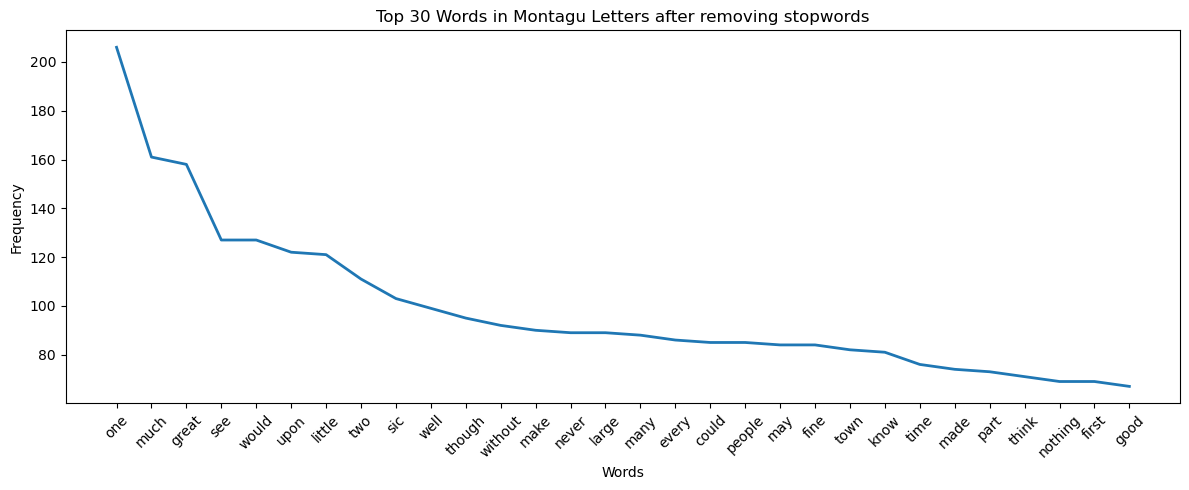

In [28]:
# Plot the top 30 words
plt.figure(figsize=(12, 5))
freq_dist_no_stopwords.plot(30, cumulative=False, show=False)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent clipping of tick-labels
plt.grid(False)# no grid
plt.title('Top 30 Words in Montagu Letters after removing stopwords')
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

<div style="background: rgba(167, 139, 250, 0.12); border-radius: 6px; padding: 0.6em 1em; margin: 1.5em 0; font-weight: 500;">
  What does this frequency distribution tell us about the content of the letters? What do you notice about the most frequent words that survived stopword removal?
</div>

In [29]:
# Let's also look at the least common words
for word, count in freq_dist_no_stopwords.most_common()[-50:]:  # Get the last 50 least common words
    print(f"{word}: {count}")

beer: 1
flavour: 1
pippins: 1
beca: 1
figuas: 1
rump: 1
beef: 1
enjoyment: 1
scanty: 1
allowance: 1
enlivening: 1
regulate: 1
employ: 1
require: 1
supposing: 1
lightning: 1
wiser: 1
virtuous: 1
brown: 1
marvellous: 1
track: 1
parishioners: 1
shield: 1
action: 1
sudden: 1
reward: 1
reproved: 1
escaped: 1
epitaph: 1
oddly: 1
lighten: 1
sadly: 1
frighten: 1
shelter: 1
beneath: 1
cocking: 1
hay: 1
seizing: 1
breath: 1
consign: 1
shades: 1
kindly: 1
fun: 1
cockold: 1
swain: 1
jointly: 1
curs: 1
chain: 1
pens: 1
inquires: 1


### Approach 2: Remove top N words

While the stopwords list gave us a set of concrete words to remove, we can also approach removing the most frequent words from a corpus specific perspective. The most common words in this corpus are the ones that appear the most. We can take a look at our most frequent words without any filtering to determine how much from the top we should trim.

In [32]:
freq_dist_all = FreqDist(all_tokens)
print(f"Unique tokens: {len(freq_dist_all)}")
freq_dist_all.most_common(20)

Unique tokens: 6355


[('the', 3438),
 ('of', 2568),
 ('to', 1668),
 ('and', 1638),
 ('i', 1499),
 ('a', 1233),
 ('in', 1084),
 ('is', 852),
 ('that', 849),
 ('with', 649),
 ('it', 564),
 ('are', 536),
 ('you', 522),
 ('not', 501),
 ('they', 488),
 ('but', 481),
 ('have', 468),
 ('their', 468),
 ('as', 463),
 ('very', 457)]

We have 59163 token and 3438 of them or about 17% are 'the'... 

In [33]:
# experiment with N — start with 50 and adjust
top_n = 50
frequent_words = set([word for word, count in freq_dist_all.most_common(top_n)])
print(f"Words being removed:\n{frequent_words}")

Words being removed:
{'than', 'and', 'my', 'not', 'their', 'for', 'from', 'but', 'so', 'we', 'at', 'there', 'they', 'she', 'the', 'me', 'them', 'on', 'this', 'are', 'in', 'of', 'being', 'i', 'with', 'to', 'which', 'am', 'a', 'you', 'or', 'her', 'his', 'by', 'much', 'here', 'as', 'all', 'be', 'that', 'can', 'no', 'have', 'an', 'very', 'is', 'had', 'one', 'was', 'it'}


They seem to be all stopwords. Maybe we can remove a bit more?

In [34]:
# experiment with N — 100
top_n = 100
frequent_words = set([word for word, count in freq_dist_all.most_common(top_n)])
print(f"Words being removed:\n{frequent_words}")

Words being removed:
{'than', 'and', 'my', 'made', 'when', 'know', 'so', 'she', 'little', 'our', 'are', 'i', 'after', 'same', 'her', 'make', 'much', 'he', 'may', 'as', 'any', 'be', 'has', 'will', 'have', 'though', 'into', 'had', 'was', 'their', 'without', 'from', 'but', 'never', 'every', 'would', 'there', 'they', 'if', 'me', 'on', 'of', 'him', 'am', 'well', 'a', 'no', 'two', 'town', 'people', 'not', 'more', 'been', 'your', 'we', 'at', 'the', 'time', 'such', 'many', 'to', 'what', 'large', 'you', 'or', 'sic', 'could', 'most', 'here', 'all', 'great', 'an', 'being', 'one', 'which', 'these', 'for', 'upon', 'those', 'it', 'see', 'them', 'this', 'in', 'other', 'where', 'with', 'were', 'own', 'by', 'who', 'that', 'can', 'some', 'fine', 'now', 'very', 'is', 'do', 'his'}


There are still a lot of stopwords but some slightly more useful words snuck in: `great, fine, little, town, time, people` but it is worth the try

In [35]:
# filter them out
tokens_no_frequent = [t for t in all_tokens if t not in frequent_words]
freq_dist_no_frequent = FreqDist(tokens_no_frequent)

print(f"Tokens remaining: {len(tokens_no_frequent)}")
print(f"Unique tokens remaining: {len(freq_dist_no_frequent)}")
print(f"\nTop 20 after removing top {top_n} most frequent:")
freq_dist_no_frequent.most_common(20)

Tokens remaining: 25604
Unique tokens remaining: 6255

Top 20 after removing top 100 most frequent:


[('part', 73),
 ('think', 71),
 ('only', 70),
 ('nothing', 69),
 ('first', 69),
 ('should', 69),
 ('good', 67),
 ('believe', 67),
 ('ladies', 65),
 ('lady', 63),
 ('give', 62),
 ('out', 62),
 ('tell', 62),
 ('yet', 62),
 ('manner', 62),
 ('us', 61),
 ('up', 61),
 ('seen', 61),
 ('having', 61),
 ('court', 61)]

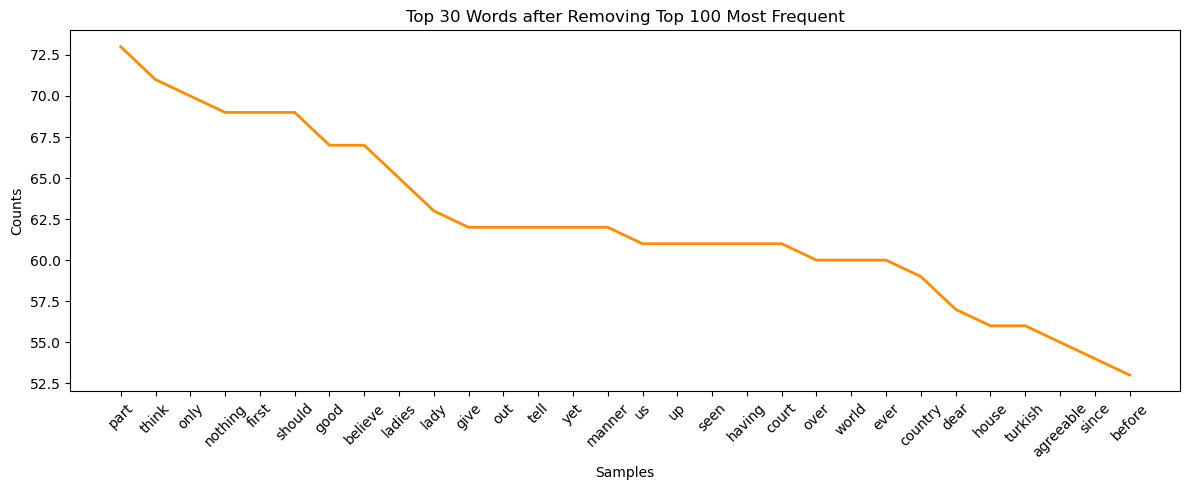

In [36]:
plt.figure(figsize=(12, 5))
freq_dist_no_frequent.plot(30, cumulative=False, show=False, color='darkorange')
plt.xticks(rotation=45)
plt.title(f'Top 30 Words after Removing Top {top_n} Most Frequent')
plt.tight_layout()
plt.grid(False)# no grid
plt.show()

### Approach 3: Removing words based on per-letter frequency

We can also approach this question of word frequency through individual letters. We Montagu talks about is in part what makes each letter distinctive. If she is using a word every where, it becomes so ubiquitous that it does not really say much about its contents. For example, the word `letter`. It is a content word but in a collection of letters, it is not a distinctive word, neither is `dear` or `lady` or even `sister` in Montagu's case.

Let's experiment with removing words that appear in 90% or more of the letters and see what happens.

In [42]:
# how many letters does each word appear in?
letter_tokens = [
    set(word.lower() for word in word_tokenize(letter) if word.isalpha())
    for letter in montagu['body']
]

In [43]:
word_letter_counts = Counter()
for token_set in letter_tokens:
    word_letter_counts.update(token_set)

In [46]:
# words appearing in 90% or more of letters
presence_threshold = 0.9
min_letters = int(len(montagu) * presence_threshold)
ubiquitous_words = set(word for word, count in word_letter_counts.items() if count >= min_letters)

print(f"Words appearing in {presence_threshold*100:.0f}%+ of letters ({min_letters}+ letters):")
print(ubiquitous_words)

Words appearing in 90%+ of letters (46+ letters):
{'not', 'on', 'with', 'was', 'of', 'as', 'much', 'all', 'very', 'if', 'than', 'i', 'one', 'by', 'to', 'any', 'be', 'in', 'are', 'the', 'a', 'is', 'have', 'you', 'for', 'am', 'so', 'but', 'some', 'my', 'from', 'which', 'will', 'that', 'and', 'me', 'had', 'more', 'here', 'at', 'it', 'this'}


In [47]:
# filter them out
tokens_distinctive = [t for t in all_tokens if t not in ubiquitous_words]
freq_dist_distinctive = FreqDist(tokens_distinctive)

print(f"Tokens remaining: {len(tokens_distinctive)}")
print(f"Unique tokens remaining: {len(freq_dist_distinctive)}")
print(f"\nTop 20 most distinctive words:")
freq_dist_distinctive.most_common(20)

Tokens remaining: 33487
Unique tokens remaining: 6311

Top 20 most distinctive words:


[('they', 488),
 ('their', 468),
 ('her', 338),
 ('them', 310),
 ('his', 209),
 ('or', 205),
 ('there', 180),
 ('no', 180),
 ('she', 178),
 ('we', 171),
 ('an', 164),
 ('can', 163),
 ('being', 162),
 ('great', 158),
 ('were', 151),
 ('he', 148),
 ('has', 148),
 ('who', 143),
 ('where', 132),
 ('see', 127)]

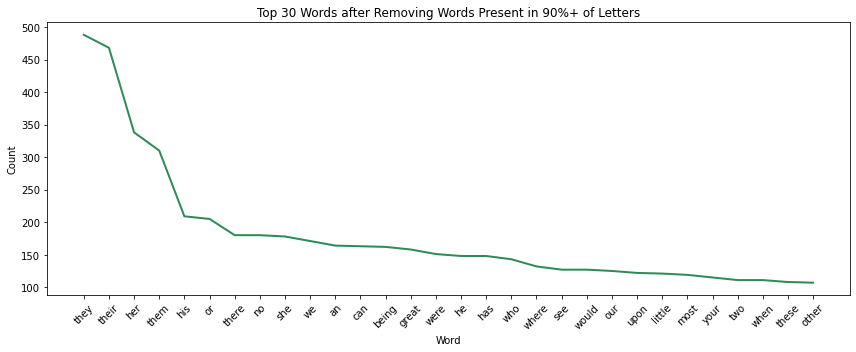

In [ ]:
plt.figure(figsize=(12, 5))
freq_dist_distinctive.plot(30, cumulative=False, show=False, color='seagreen')
plt.xticks(rotation=45)
plt.title(f'Top 30 Words after Removing Words Present in {presence_threshold*100:.0f}%+ of Letters')
plt.tight_layout()
plt.grid(False)
plt.xlabel('Word')
plt.ylabel('Count')
plt.show()

### Approach 4: Remove Stopwrods and Top N

We can also combine multiple approaches. Let's bring back our frequency distribution without stop words and then see what happens when we remove top N from it

In [55]:
# remove top N most frequent content words from the stopword-filtered tokens
top_n = 30
frequent_words_content = set([word for word, count in freq_dist_no_stopwords.most_common(top_n)])
print(f"Top {top_n} content words being removed:")
print(frequent_words_content)

Top 30 content words being removed:
{'made', 'see', 'without', 'town', 'time', 'well', 'much', 'two', 'one', 'sic', 'upon', 'would', 'never', 'nothing', 'may', 'though', 'part', 'great', 'first', 'people', 'every', 'little', 'many', 'make', 'could', 'know', 'good', 'fine', 'think', 'large'}


In [56]:
tokens_combined = [t for t in tokens_no_stopwords if t not in frequent_words_content]
freq_dist_combined = FreqDist(tokens_combined)

print(f"Tokens remaining: {len(tokens_combined)}")
print(f"Unique tokens remaining: {len(freq_dist_combined)}")
print(f"\nTop 20:")
freq_dist_combined.most_common(20)

Tokens remaining: 23950
Unique tokens remaining: 6196

Top 20:


[('believe', 67),
 ('ladies', 65),
 ('lady', 63),
 ('give', 62),
 ('tell', 62),
 ('yet', 62),
 ('manner', 62),
 ('us', 61),
 ('seen', 61),
 ('court', 61),
 ('world', 60),
 ('ever', 60),
 ('country', 59),
 ('dear', 57),
 ('house', 56),
 ('turkish', 56),
 ('agreeable', 55),
 ('since', 54),
 ('say', 52),
 ('saw', 51)]

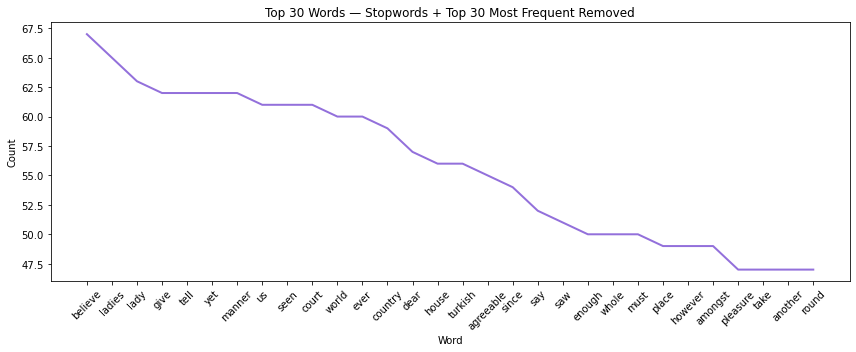

In [58]:
plt.figure(figsize=(12, 5))
freq_dist_combined.plot(30, cumulative=False, show=False, color='mediumpurple')
plt.xticks(rotation=45)
plt.title(f'Top 30 Words — Stopwords + Top {top_n} Most Frequent Removed')
plt.tight_layout()
plt.grid(False)
plt.xlabel('Word')
plt.ylabel('Count')
plt.show()

<div style="background: rgba(167, 139, 250, 0.12); border-radius: 6px; padding: 0.6em 1em; margin: 1.5em 0; font-weight: 500;">
Let's take a moment and think about all these different approaches. What did you learn from this exercise about Montagu's letters?
</div>

All that is to say, it is not super straightforward to work with word frequencies, especially in a corpus of this size (60k words) and with historical spelling variations that impacts the quality of the downstream analysis.

This is a heuristic, so please don't take it as a strong rule. Word frequencies are generally more powerful, in terms of their explanatory power, in corpora with 1m or more words.

We will need to experiment with more fine-grained approaches to tackle questions of meaning in our letters.

---
## Step 4: Bigrams

Individual words can be ambiguous. "Grand" means something different in "grand tour" than in "grand piano." **Bigrams** — pairs of adjacent words — preserve some of that context.

Think of bigrams as a window of size 2 sliding across the text:

> `I have had the advantage` → `(I, have)`, `(have, had)`, `(had, the)`, `(the, advantage)` …

In [37]:
bigram_freq = Counter()

for letter in montagu['body'].tolist():
    # tokenize, lowercase, keep only alphabetic tokens, remove stopwords
    tokens = [
        word.lower() for word in word_tokenize(letter)
        if word.isalpha() and word.lower() not in stop_words
    ]
    bigram_freq.update(bigrams(tokens))

print("Top 20 bigrams:")
for bigram, count in bigram_freq.most_common(20):
    print(f"{bigram[0]} {bigram[1]}: {count}")

Top 20 bigrams:
dear sister: 26
mr w: 19
grand signior: 18
one another: 15
look upon: 13
take care: 11
great deal: 11
every thing: 11
part world: 11
white marble: 11
never saw: 10
dear madam: 10
years old: 10
could forbear: 9
make use: 9
looked upon: 9
every day: 8
well pleased: 8
dear lady: 8
every body: 8


<div style="background: rgba(167, 139, 250, 0.12); border-radius: 6px; padding: 0.6em 1em; margin: 1.5em 0; font-weight: 500;">
  These are letters — what do the most common bigrams reveal about the genre? Would you expect different bigrams in, say, a newspaper or a legal document?
</div>

---
## Step 5: POS Tagging

**Part-of-Speech (POS) tagging** assigns a grammatical category to each word — noun, verb, adjective, and so on. This is a key step in many NLP pipelines because it tells us not just *what* words appear, but *what role* they play in the sentence.

POS tags typically include:

| Tag | Category | Example |
|---|---|---|
| `NN` | Noun, singular | *city, bath, letter* |
| `NNS` | Noun, plural | *women, gardens, letters* |
| `NNP` | Proper noun, singular | *Constantinople, Montagu* |
| `VBD` | Verb, past tense | *visited, wrote, observed* |
| `JJ` | Adjective | *fine, curious, Turkish* |
| `RB` | Adverb | *very, much, quite* |
| `PRP` | Personal pronoun | *I, she, they* |
| `IN` | Preposition | *in, of, at* |

NLTK's `pos_tag()` takes a list of tokens and returns a list of `(word, tag)` tuples.

In [38]:
# Let's start with Letter 35 again — one sentence
sentences = sent_tokenize(letter_35)
sample_sentence = sentences[0]
print(sample_sentence)

I HAVE had the advantage of very fine weather, all my journey; and as
the summer is now in its beauty, I enjoyed the pleasure of fine
prospects; and the meadows being full of all sorts of garden flowers,
and sweet herbs, my berlin perfumed the air as it pressed them.


In [39]:
# Apply POS tagging to the first sentence
pos_tags = pos_tag(word_tokenize(sample_sentence))
pos_tags

[('I', 'PRP'),
 ('HAVE', 'VBP'),
 ('had', 'VBD'),
 ('the', 'DT'),
 ('advantage', 'NN'),
 ('of', 'IN'),
 ('very', 'RB'),
 ('fine', 'JJ'),
 ('weather', 'NN'),
 (',', ','),
 ('all', 'DT'),
 ('my', 'PRP$'),
 ('journey', 'NN'),
 (';', ':'),
 ('and', 'CC'),
 ('as', 'IN'),
 ('the', 'DT'),
 ('summer', 'NN'),
 ('is', 'VBZ'),
 ('now', 'RB'),
 ('in', 'IN'),
 ('its', 'PRP$'),
 ('beauty', 'NN'),
 (',', ','),
 ('I', 'PRP'),
 ('enjoyed', 'VBD'),
 ('the', 'DT'),
 ('pleasure', 'NN'),
 ('of', 'IN'),
 ('fine', 'JJ'),
 ('prospects', 'NNS'),
 (';', ':'),
 ('and', 'CC'),
 ('the', 'DT'),
 ('meadows', 'NNS'),
 ('being', 'VBG'),
 ('full', 'JJ'),
 ('of', 'IN'),
 ('all', 'DT'),
 ('sorts', 'NNS'),
 ('of', 'IN'),
 ('garden', 'NN'),
 ('flowers', 'NNS'),
 (',', ','),
 ('and', 'CC'),
 ('sweet', 'JJ'),
 ('herbs', 'NN'),
 (',', ','),
 ('my', 'PRP$'),
 ('berlin', 'NN'),
 ('perfumed', 'VBD'),
 ('the', 'DT'),
 ('air', 'NN'),
 ('as', 'IN'),
 ('it', 'PRP'),
 ('pressed', 'VBD'),
 ('them', 'PRP'),
 ('.', '.')]

### Extracting adjectives

Adjectives can tell us a lot about tone and sentiment. Let's write a function to extract them.

Note that we use a simple heuristic to reduce false positives: we only keep a word tagged `JJ` if the *next* word is a noun (`NN`). This filters out cases where the tagger mislabels a word as an adjective.

Like:
```python
...
('of', 'IN'),
('fine', 'JJ'),
('prospects', 'NNS'),
(';', ':'),
 ...
```

vs

```python
...
('being', 'VBG'),
('full', 'JJ'),
('of', 'IN'),
('all', 'DT'),
...
```



In [40]:
def extract_adjectives(text):
    """Extract adjectives that directly precede a noun."""
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)
    adjectives = []
    for i in range(len(tagged) - 1):
        word, tag = tagged[i]
        next_word, next_tag = tagged[i + 1]
        if tag.startswith('JJ') and next_tag.startswith('NN') and len(word) >= 3:
            adjectives.append(word.lower())
    return adjectives

We just wrote out first function together :D Let's take a closer look at it:

- `def extract_adjectives(text):` — defines a reusable function that takes a text string as input
- `tokens = word_tokenize(text)` — splits the text into tokens and lowercases everything for consistency
- `tagged = pos_tag(tokens)` — assigns a POS tag to each token, giving us a list of `(word, tag)` tuples
- `adjectives = []` — creates an empty list to collect our results
- `for i in range(len(tagged) - 1):` — loops through each word by its position; we stop one before the end so we can always look at the next word without going out of bounds
- `word, tag = tagged[i]` — unpacks the current `(word, tag)` tuple into two variables
- `next_word, next_tag = tagged[i + 1]` — does the same for the following word
- `if tag.startswith('JJ') and next_tag.startswith('NN') and len(word) >= 3:` — our *heuristic*: only keep the word if it is tagged as an adjective AND the next word is a noun and if the tagged word is longer than 2 characters. There are no English adjectives that are only 2 characters long, so this criteria helps against false positives.
- `adjectives.append(word.lower())` — if both conditions are met, add the word to our list in lowercased
- `return adjectives` — sends the final list back to whoever called the function

In [41]:
# Test on Letter 35
letter_35_adjectives = extract_adjectives(letter_35)
print(f"Adjectives in Letter 35: {letter_35_adjectives}")

Adjectives in Letter 35: ['fine', 'fine', 'sweet', 'grand', 'great', 'little', 'grand', 'thick', 'little', 'turkish', 'ancient', 'next', 'noble', 'good', 'thirty-two', 'famous', 'greek', 'ill-built', 'same', 'roman-catholic', 'finest', 'monstrous', 'more', 'good', 'pleasant', 'large', 'marble', 'good', 'own', 'tall', 'nest', 'fifty', 'best', 'next', 'good', 'young', 'high', 'distant', 'beautiful', 'own', 'whole', 'vast', 'several', 'inconsiderable', 'great', 'other', 'ancient', 'fine', 'different', 'simple', 'other', 'particular', 'great', 'solemn', 'other', 'other', 'forth', 'public', 'vulgar', 'celestial', 'inferior', 'good', 'eternal', 'ten', 'useless', 'perpetual', 'greek', 'professed', 'valuable', 'macedonian', 'greek', 'great', 'best', 'greek', 'same', 'great', 'considerable', 'old', 'close', 'famous']


In [42]:
# Apply to all letters and store in a new column
montagu['adjectives'] = montagu['body'].apply(extract_adjectives)
montagu[['title', 'adjectives']].head()

,title,adjectives
0,﻿LETTER 1.,"[dear, ill, dry, little, new, broad, meanest, ..."
1,LET. II,"[dreadful, short, sure, whole, large, large, l..."
2,LET. III,"[dear, agreeable, more, same, same, considerab..."
3,LET. IV.,"[last, great, indifferent, first, thousand, wr..."
4,LET. V.,"[other, dear, large, free, little, dirty, nast..."


In [77]:
montagu.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   filename        52 non-null     str   
 1   title           52 non-null     str   
 2   body            52 non-null     str   
 3   word_count      52 non-null     int64 
 4   sentence_count  52 non-null     int64 
 5   adjectives      52 non-null     object
dtypes: int64(2), object(1), str(3)
memory usage: 2.6+ KB


In [43]:
# Flatten into one list and count
all_adjectives = list(chain.from_iterable(montagu['adjectives']))
adjective_counts = Counter(all_adjectives)

print("Top 15 adjectives across all letters:")
for adj, count in adjective_counts.most_common(15):
    print(f"  {adj}: {count}")

Top 15 adjectives across all letters:
  great: 141
  other: 83
  little: 79
  same: 79
  fine: 56
  own: 55
  large: 53
  good: 53
  first: 43
  many: 43
  turkish: 43
  whole: 42
  dear: 41
  young: 36
  much: 32


That was fast! Let's slow down for a second and take a look at what we did here:

```python
all_adjectives = list(chain.from_iterable(montagu['adjectives']))
```

`montagu['adjectives']` is a column of lists — each cell contains a list of adjectives from one letter. We need to flatten this into a single list of all adjectives across all letters.

`chain.from_iterable()` does exactly that — it chains all the inner lists together into one continuous sequence, and `list()` converts it into a regular Python list.

This is equivalent to:

```python
all_adjectives = []
for adjective_list in montagu['adjectives']:
    all_adjectives.extend(adjective_list)
```

Remember the difference between `.extend()` and `.append()` from 1-6_data-structures?

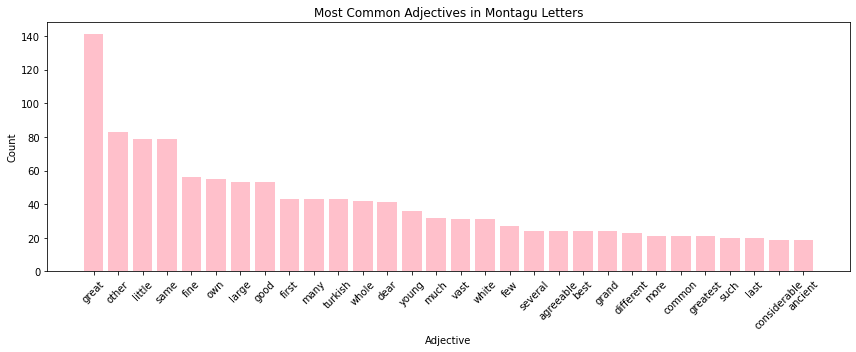

In [80]:
# Visualize
top_adj = adjective_counts.most_common(30)
adjs, counts = zip(*top_adj)

plt.figure(figsize=(12, 5))
plt.bar(adjs, counts, color='pink')
plt.title('Most Common Adjectives in Montagu Letters')
plt.xlabel('Adjective')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Extracting nouns

While adjectives hint at sentiment and tone, **nouns** get us closer to the *topics* of the letters — the places, people, and things Montagu writes about.

Nouns in English come in several forms, each with their own POS tag:

- `NN` — singular common noun: *bath, letter, woman*
- `NNS` — plural common noun: *baths, letters, women*
- `NNP` — singular proper noun: *Constantinople, Adrianople*
- `NNPS` — plural proper noun: *Ottomans, Europeans*

In [44]:
# First, get POS tags for all letters and store them
# this way we don't have to recalculate it 
montagu['pos_tags'] = montagu['body'].apply(lambda x: pos_tag(word_tokenize(x)))

In [45]:
# let's create a set of noun tags

noun_tags = {'NN', 'NNS', 'NNP', 'NNPS'}

In [ ]:
# Let's create another function, this time for extracting nouns

### YOUR CODE HERE

In [46]:
# This is how I would do it

def extract_nouns(pos_tag_list):
    """Extract all nouns from a list of (word, tag) tuples."""
    nouns = []
    for word, tag in pos_tag_list:
        if tag in noun_tags and word.isalpha() and len(word) > 2:
            nouns.append(word.lower())
    return nouns

In [47]:
# Finally, let's apply it to our df
montagu['nouns'] = montagu['pos_tags'].apply(extract_nouns)
montagu[['title', 'nouns']].head()

,title,nouns
0,﻿LETTER 1.,"[flatter, sister, pleasure, sea, fortune, stor..."
1,LET. II,"[haste, madam, fatigues, journey, care, stages..."
2,LET. III,"[fears, relations, fears, health, safety, happ..."
3,LET. IV.,"[lady, notion, fatigues, days, proof, regard, ..."
4,LET. V.,"[after, days, post, occasion, lady, obliging, ..."


`extract_nouns()` seems very similar to `extract_adjectives()` but there is a crucial difference. `extract_adjectives()` operates on a string. `extract_nouns()` operates on a list of (word, tag) tuples. This is why we should make it clear for each function what it takes in and what it returns. You want to be able to remember all this a year later and you can't always count on your memory

In [48]:
# Flatten and count
all_nouns = list(chain.from_iterable(montagu['nouns']))
noun_counts = Counter(all_nouns)

print("Top 15 nouns across all letters:")
for noun, count in noun_counts.most_common(15):
    print(f"  {noun}: {count}")

Top 15 nouns across all letters:
  people: 85
  town: 82
  time: 76
  part: 73
  nothing: 69
  ladies: 64
  manner: 62
  court: 61
  world: 60
  country: 59
  house: 56
  lady: 55
  place: 48
  pleasure: 47
  day: 46


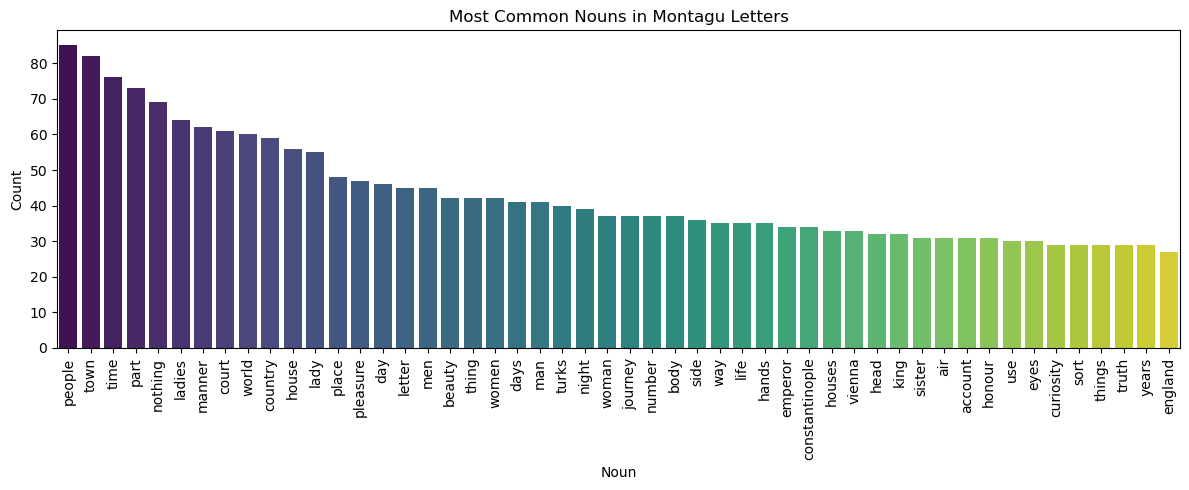

In [49]:
# Visualize top 50 nouns
top_nouns = noun_counts.most_common(50)
nouns, counts = zip(*top_nouns)

plt.figure(figsize=(12, 5))
sns.barplot(x=list(nouns), y=list(counts), hue=list(nouns), palette='viridis', legend=False)
plt.title('Most Common Nouns in Montagu Letters')
plt.xlabel('Noun')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

<div style="background: rgba(167, 139, 250, 0.12); border-radius: 6px; padding: 0.6em 1em; margin: 1.5em 0; font-weight: 500;">
  Nouns tell a different story from adjectives. Compare the two charts — what does each one reveal about the letters that the other doesn't?
</div>

---
## Step 6: Lemmatization

Our noun and adjective counts work well, but they still treat inflected forms as separate words. For example:

- `woman` and `women` are counted separately
- `great`, `greater`, `greatest` are counted separately
- `observed`, `observing`, `observes` are counted separately

**Lemmatization** reduces each word to its **lemma** — the base dictionary form. This gives us a more accurate picture of the vocabulary.

It is different from **stemming** (which you may have heard of), which just chops off suffixes and can produce non-words like `observ`. Lemmatization produces real words.

| Word | Stemmed | Lemmatized |
|---|---|---|
| `women` | `women` | `woman` |
| `observed` | `observ` | `observe` |
| `greater` | `greater` | `great` |
| `ladies` | `ladi` | `lady` |

In [51]:
lemmatizer = WordNetLemmatizer()

# Basic usage — defaults to treating the word as a noun
print(lemmatizer.lemmatize('women'))     # woman
print(lemmatizer.lemmatize('ladies'))    # lady
print(lemmatizer.lemmatize('observed'))  # observed — not right yet!

woman
lady
observed


In [60]:
print(lemmatizer.lemmatize('Kujuk Cekmege'))

Kujuk Cekmege


Notice that `observed` didn't lemmatize correctly. That's because the lemmatizer defaults to treating every word as a **noun**. `observed` is a verb, so we need to tell it that.

This is where POS tags become really useful — we already have them! We just need to convert the NLTK POS tag format (e.g. `VBD`) into the format WordNet understands (`v` for verb, `n` for noun, `a` for adjective, `r` for adverb).

In [52]:
from nltk.corpus import wordnet

def get_wordnet_pos(treebank_tag):
    """Convert a Treebank POS tag to a WordNet POS tag."""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default to noun

This is a helper function that translates between two different POS tag systems — NLTK uses one format (e.g. `JJ`, `VBD`, `NN`) while WordNet, which powers our lemmatizer, uses another (`a`, `v`, `n`, `r`). You don't need to worry about the internals — just know that we need it for the lemmatizer to work correctly, and we will call it in the next cell.

In [53]:
# Now lemmatize correctly using the POS tag
print(lemmatizer.lemmatize('observed', get_wordnet_pos('VBD')))   # observe ✓
print(lemmatizer.lemmatize('greater',  get_wordnet_pos('JJR')))   # great ✓
print(lemmatizer.lemmatize('ladies',   get_wordnet_pos('NNS')))   # lady ✓
print(lemmatizer.lemmatize('quickly',  get_wordnet_pos('RB')))    # quickly (already base form)

observe
great
lady
quickly


In [54]:
def lemmatize_text(pos_tag_list):
    """Lemmatize all words in a (word, tag) list, skipping punctuation."""
    lemmas = []
    for word, tag in pos_tag_list:
        if word.isalpha():
            wordnet_pos = get_wordnet_pos(tag)
            lemma = lemmatizer.lemmatize(word.lower(), wordnet_pos)
            lemmas.append(lemma)
    return lemmas

In [55]:
# Apply to all letters — we already have pos_tags stored!
montagu['lemmas'] = montagu['pos_tags'].apply(lemmatize_text)
montagu[['title', 'lemmas']].head()

,title,lemmas
0,﻿LETTER 1.,"[i, flatter, myself, dear, sister, that, i, sh..."
1,LET. II,"[i, make, haste, to, tell, you, dear, madam, t..."
2,LET. III,"[i, be, extremely, sorry, my, dear, that, your..."
3,LET. IV.,"[if, my, lady, could, have, any, notion, of, t..."
4,LET. V.,"[after, five, day, travel, post, i, could, not..."


In [56]:
# remove stopwords from lemmas
all_lemmas = list(chain.from_iterable(montagu['lemmas']))
lemmas_no_stopwords = [l for l in all_lemmas if l not in stop_words]

In [57]:
# Compare
raw_counts = Counter(tokens_no_stopwords) # from setp 3
lemma_counts = Counter(lemmas_no_stopwords)

print("Raw token counts (top 15):")
for word, count in raw_counts.most_common(15):
    print(f"  {word}: {count}")

print("\nLemma counts (top 15):")
for word, count in lemma_counts.most_common(15):
    print(f"  {word}: {count}")

Raw token counts (top 15):
  one: 206
  much: 161
  great: 158
  see: 127
  would: 127
  upon: 122
  little: 121
  two: 111
  sic: 103
  well: 99
  though: 95
  without: 92
  make: 90
  never: 89
  large: 89

Lemma counts (top 15):
  one: 213
  see: 211
  make: 206
  great: 188
  much: 161
  give: 136
  would: 127
  lady: 127
  upon: 122
  little: 121
  know: 119
  two: 111
  take: 110
  well: 108
  fine: 106


<div style="background: rgba(167, 139, 250, 0.12); border-radius: 6px; padding: 0.6em 1em; margin: 1.5em 0; font-weight: 500;">
  Compare the two lists. Which words changed rank after lemmatization? Can you spot any cases where different inflected forms have been merged together?
</div>

In [58]:
# A concrete example: how does lemmatization affect the noun 'lady'?
print("'lady' in raw tokens:", raw_counts.get('lady', 0))
print("'ladies' in raw tokens:", raw_counts.get('ladies', 0))
print("'lady' after lemmatization:", lemma_counts.get('lady', 0))

'lady' in raw tokens: 63
'ladies' in raw tokens: 65
'lady' after lemmatization: 127


### A note on lemmatization for multilingual text

NLTK's `WordNetLemmatizer` only works for **English**. For other languages you need different tools:

- **spaCy** has lemmatizers for many languages (French, German, Spanish, Arabic, Chinese, and more)
- **Stanza** (from Stanford NLP) supports 70+ languages
- **HuggingFace** is a great place to start for finding the state of the art models for this and any other NLP task.

The *concept* of lemmatization is the same across languages — reduce a word to its dictionary form — but what that means varies. In highly inflected languages like Arabic or Turkish, lemmatization collapses far more forms than in English, making it an even more important preprocessing step.

---
## Save your work

In [97]:
# Save the enriched DataFrame
montagu.to_csv('../../output/montagu_letters_v3.csv', index=False)
print("Saved! Columns now:", montagu.columns.tolist())

Saved! Columns now: ['filename', 'title', 'body', 'word_count', 'sentence_count', 'adjectives', 'pos_tags', 'nouns', 'lemmas']
